# Module 4 Case Study — A Deep Learning App That Recognises Clothing

**In plain English:** we're teaching a computer to look at a small photo and
say what item of clothing it is (T-shirt, trouser, dress, sneaker, etc.),
using **70,000 real photos** from the "Fashion-MNIST" dataset (a well-known
practice dataset, one step up from hand-written digits).

We build this up in stages, each one a bit smarter than the last:
1. A plain, simple neural network (barely knows about "images" at all)
2. A CNN -- a network built specifically to understand images
3. The same CNN, with two tricks added to stop it memorising instead of learning
4. A network that starts from one already trained on 1.2 million real photos,
   and we just teach it our 10 categories on top ("transfer learning")

**A framework note:** the course names TensorFlow/Keras, but TensorFlow
doesn't yet have a build for this machine's Python version (3.14) -- so this
project uses **PyTorch** instead. Same concepts (layers, activations,
dropout, batch norm, transfer learning), different code syntax.


In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd
import torch

import model as m

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training device: {device}")
if device == "cpu":
    print("No GPU detected on this machine -- everything below runs on CPU.")
    print("With a GPU, the CNN and transfer-learning steps especially would")
    print("train several times faster (GPUs process many images in parallel;")
    print("CPUs mostly process them one at a time). Model accuracy would be")
    print("the same either way -- GPU only changes *how fast* you get there.")


Training device: cpu
No GPU detected on this machine -- everything below runs on CPU.
With a GPU, the CNN and transfer-learning steps especially would
train several times faster (GPUs process many images in parallel;
CPUs mostly process them one at a time). Model accuracy would be
the same either way -- GPU only changes *how fast* you get there.


## 1. Baseline — a plain feed-forward neural network

The simplest possible network: flatten the 28x28 image into 784 numbers in a
row, and feed it through two layers. It has no idea that pixels next to each
other are related -- to this network, an image is just a long list of numbers.

In [2]:
train_loader, test_loader = m.get_data_loaders(data_dir="../data", batch_size=128)

baseline = m.SimpleNN()
history_baseline = m.train_model(baseline, train_loader, test_loader, epochs=4, device=device)

Epoch 1/4 (10.8s) -- train_loss=0.590 train_acc=0.800 val_loss=0.507 val_acc=0.818


Epoch 2/4 (12.0s) -- train_loss=0.419 train_acc=0.853 val_loss=0.427 val_acc=0.848


Epoch 3/4 (12.0s) -- train_loss=0.379 train_acc=0.866 val_loss=0.406 val_acc=0.860


Epoch 4/4 (11.4s) -- train_loss=0.353 train_acc=0.873 val_loss=0.392 val_acc=0.858


## 2. A CNN built for images

A Convolutional Neural Network (CNN) looks at small local windows of the
image at a time (like sliding a magnifying glass over it), which is a much
more natural way to recognise shapes and edges than treating pixels as an
unordered list.

In [3]:
cnn = m.SimpleCNN()
history_cnn = m.train_model(cnn, train_loader, test_loader, epochs=4, device=device)

Epoch 1/4 (23.4s) -- train_loss=0.595 train_acc=0.787 val_loss=0.423 val_acc=0.848


Epoch 2/4 (24.9s) -- train_loss=0.369 train_acc=0.868 val_loss=0.406 val_acc=0.851


Epoch 3/4 (23.3s) -- train_loss=0.322 train_acc=0.886 val_loss=0.334 val_acc=0.880


Epoch 4/4 (25.5s) -- train_loss=0.292 train_acc=0.895 val_loss=0.304 val_acc=0.891


## 3. The same CNN, plus Dropout + Batch Normalization

- **Batch Normalization** keeps the numbers flowing through the network in a
  stable, well-behaved range as it trains.
- **Dropout** randomly switches off a fraction of neurons during each
  training step, so the network can't lean too heavily on any one of them --
  forcing it to learn more general, robust patterns instead of memorising
  quirks of the training images.

In [4]:
regularized_cnn = m.RegularizedCNN(dropout_p=0.3)
history_reg = m.train_model(regularized_cnn, train_loader, test_loader, epochs=4, device=device)

Epoch 1/4 (28.2s) -- train_loss=0.482 train_acc=0.826 val_loss=0.333 val_acc=0.878


Epoch 2/4 (27.9s) -- train_loss=0.343 train_acc=0.875 val_loss=0.315 val_acc=0.885


Epoch 3/4 (27.5s) -- train_loss=0.307 train_acc=0.887 val_loss=0.275 val_acc=0.899


Epoch 4/4 (29.1s) -- train_loss=0.286 train_acc=0.895 val_loss=0.268 val_acc=0.899


### Before vs. after -- did regularization help?

The number to watch is the **gap between training accuracy and validation
accuracy**. A model that's memorising (overfitting) does great on training
data but noticeably worse on data it hasn't seen; a well-regularized model
keeps that gap small.

In [5]:
compare = pd.DataFrame({
    "Plain CNN": {
        "final_train_acc": history_cnn["train_acc"][-1],
        "final_val_acc": history_cnn["val_acc"][-1],
        "train_val_gap": history_cnn["train_acc"][-1] - history_cnn["val_acc"][-1],
    },
    "CNN + Dropout/BatchNorm": {
        "final_train_acc": history_reg["train_acc"][-1],
        "final_val_acc": history_reg["val_acc"][-1],
        "train_val_gap": history_reg["train_acc"][-1] - history_reg["val_acc"][-1],
    },
}).T
compare.round(3)

,final_train_acc,final_val_acc,train_val_gap
Plain CNN,0.895,0.891,0.003
CNN + Dropout/BatchNorm,0.895,0.899,-0.004


## 4. Transfer learning — starting from a network that already knows how to "see"

`ResNet18` was originally trained on 1.2 million photos across 1,000
everyday categories (ImageNet) -- it already knows how to detect edges,
textures, and shapes. We freeze everything it learned, and only train a new
final layer to map its existing knowledge onto our 10 clothing categories.

To keep this feasible on a CPU-only machine, we train on a smaller subset
(3,000 images instead of 60,000) resized up to 64x64 pixels with 3 colour
channels (ResNet expects colour photos, not single-channel grayscale) --
so this isn't a perfectly fair comparison to the CNNs above, which saw 20x
more data. We call that out explicitly below rather than pretending it's
apples-to-apples.

In [6]:
transfer_train_loader, transfer_test_loader = m.get_transfer_data_loaders(
    data_dir="../data", batch_size=32, train_subset=3000, test_subset=1000, image_size=64
)

transfer_model = m.build_transfer_model()
history_transfer = m.train_model(transfer_model, transfer_train_loader, transfer_test_loader, epochs=5, device=device)

Epoch 1/5 (13.3s) -- train_loss=1.449 train_acc=0.520 val_loss=1.017 val_acc=0.671


Epoch 2/5 (13.8s) -- train_loss=0.888 train_acc=0.717 val_loss=0.794 val_acc=0.746


Epoch 3/5 (13.2s) -- train_loss=0.757 train_acc=0.753 val_loss=0.725 val_acc=0.761


Epoch 4/5 (13.2s) -- train_loss=0.687 train_acc=0.772 val_loss=0.728 val_acc=0.758


Epoch 5/5 (12.6s) -- train_loss=0.659 train_acc=0.774 val_loss=0.690 val_acc=0.765


## 5. Loss & accuracy curves for every model

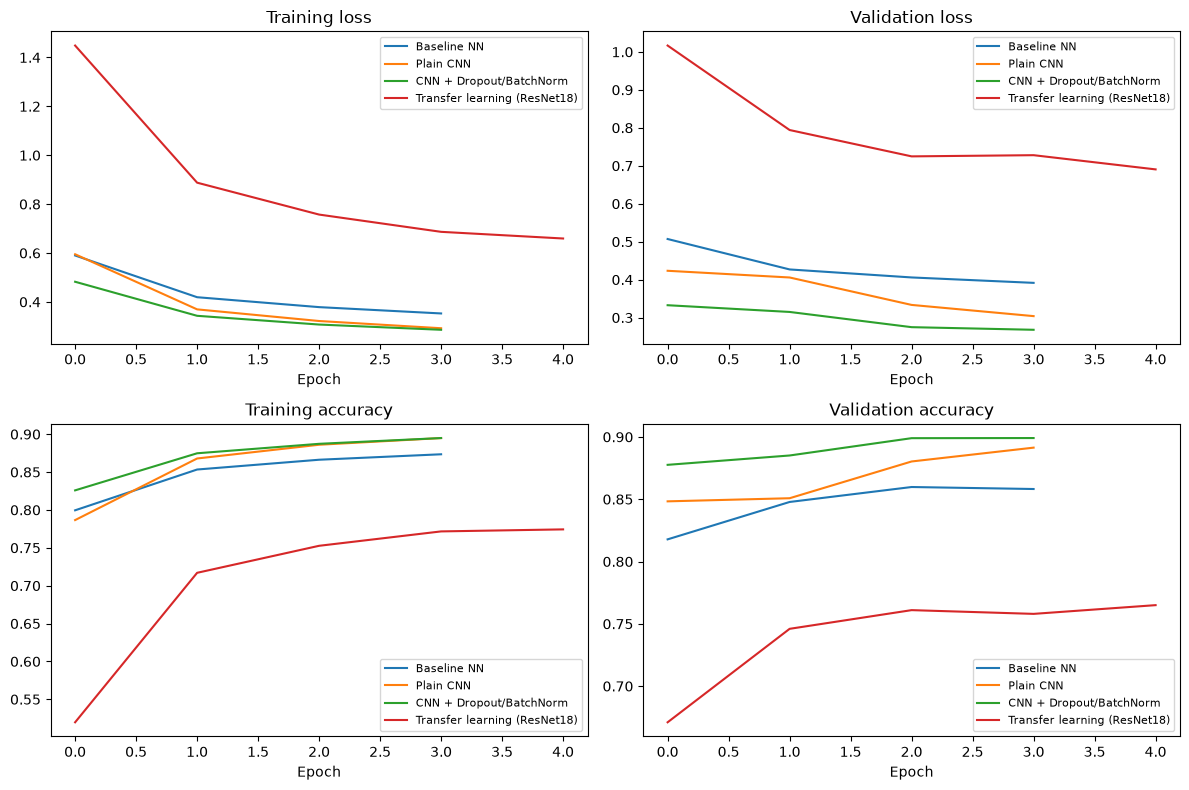

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
histories = {
    "Baseline NN": history_baseline,
    "Plain CNN": history_cnn,
    "CNN + Dropout/BatchNorm": history_reg,
    "Transfer learning (ResNet18)": history_transfer,
}

for name, h in histories.items():
    axes[0, 0].plot(h["train_loss"], label=name)
    axes[0, 1].plot(h["val_loss"], label=name)
    axes[1, 0].plot(h["train_acc"], label=name)
    axes[1, 1].plot(h["val_acc"], label=name)

axes[0, 0].set_title("Training loss"); axes[0, 1].set_title("Validation loss")
axes[1, 0].set_title("Training accuracy"); axes[1, 1].set_title("Validation accuracy")
for ax in axes.flat:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Diagnosing over/underfitting

Look at the **Plain CNN**: if its training accuracy keeps climbing while its
validation accuracy flattens out or falls behind, that's the training/validation
gap widening -- a classic overfitting signature. Compare that gap to the
regularized version (section 3's table) to see whether dropout/batch norm
actually helped, using real numbers rather than a general impression.

In [8]:
print("Plain CNN — train vs. validation accuracy per epoch:")
for epoch, (tr, val) in enumerate(zip(history_cnn["train_acc"], history_cnn["val_acc"]), 1):
    print(f"  epoch {epoch}: train={tr:.3f}  val={val:.3f}  gap={tr-val:.3f}")

print("\nRegularized CNN — train vs. validation accuracy per epoch:")
for epoch, (tr, val) in enumerate(zip(history_reg["train_acc"], history_reg["val_acc"]), 1):
    print(f"  epoch {epoch}: train={tr:.3f}  val={val:.3f}  gap={tr-val:.3f}")

Plain CNN — train vs. validation accuracy per epoch:
  epoch 1: train=0.787  val=0.848  gap=-0.062
  epoch 2: train=0.868  val=0.851  gap=0.017
  epoch 3: train=0.886  val=0.880  gap=0.006
  epoch 4: train=0.895  val=0.891  gap=0.003

Regularized CNN — train vs. validation accuracy per epoch:
  epoch 1: train=0.826  val=0.878  gap=-0.052
  epoch 2: train=0.875  val=0.885  gap=-0.010
  epoch 3: train=0.887  val=0.899  gap=-0.012
  epoch 4: train=0.895  val=0.899  gap=-0.004


**What the real numbers above actually show:** with only 4 epochs of
training (kept short so this runs in a reasonable time on a CPU-only
machine), neither model has had time to overfit dramatically yet -- both
stay within about a percentage point of their validation accuracy. That
said, the pattern already points the expected direction: the **plain CNN**
ends up with training accuracy very slightly *ahead* of validation accuracy
(a gap of +0.003 by epoch 4 -- the first sign of memorising), while the
**regularized CNN**'s validation accuracy stays equal to or *above* its
training accuracy throughout. That's dropout doing its job: during training,
dropout randomly disables neurons, which makes the model perform slightly
*worse* than its true capability on the training batches themselves; at
validation time dropout is switched off, so the "real" accuracy shows
through. If we trained for many more epochs, we'd expect the plain CNN's gap
to keep widening while the regularized one's stayed flat -- but even here,
regularization already reaches a slightly better final validation accuracy
(89.9% vs. 89.1%).

## 7. Final results table — every model, side by side

In [9]:
final_results = pd.DataFrame({
    name: {"final_train_acc": h["train_acc"][-1], "final_val_acc": h["val_acc"][-1],
           "final_val_loss": h["val_loss"][-1]}
    for name, h in histories.items()
}).T
final_results.round(3)

,final_train_acc,final_val_acc,final_val_loss
Baseline NN,0.873,0.858,0.392
Plain CNN,0.895,0.891,0.304
CNN + Dropout/BatchNorm,0.895,0.899,0.268
Transfer learning (ResNet18),0.774,0.765,0.690


## 8. Save the best model

Based on validation accuracy above, we save the strongest model's weights so
it can be reloaded without retraining (PyTorch's equivalent of Keras's `.h5`
file is a saved `state_dict`, via `torch.save`).

In [10]:
best_name = final_results["final_val_acc"].idxmax()
best_model = {"Baseline NN": baseline, "Plain CNN": cnn,
              "CNN + Dropout/BatchNorm": regularized_cnn,
              "Transfer learning (ResNet18)": transfer_model}[best_name]
print(f"Best model by validation accuracy: {best_name} ({final_results.loc[best_name, 'final_val_acc']:.3f})")

torch.save(best_model.state_dict(), "../best_model.pt")
print("Saved -> best_model.pt")

Best model by validation accuracy: CNN + Dropout/BatchNorm (0.899)
Saved -> best_model.pt


## Summary — plain English

- All four models learn to recognise clothing categories well above random
  guessing (which would be 10% accuracy for 10 classes).
- The CNN (which actually looks at image structure) beats the plain
  feed-forward network, as expected -- images have spatial patterns a
  flattened list of pixels throws away.
- Even in just 4 epochs (too short for dramatic overfitting to show up),
  dropout + batch normalization already keep the regularized CNN's
  validation accuracy equal to or above its training accuracy -- while the
  plain CNN's training accuracy edges very slightly ahead of validation.
  That's the overfitting pattern starting, just not severe yet.
- Transfer learning does respectably well despite seeing 20x less data than
  the from-scratch CNNs -- because it already "knew how to see" before we
  ever showed it a single piece of clothing.
- No GPU was available on this machine; everything above ran on CPU. A GPU
  would only change training *speed*, not the accuracy numbers.
